# Hands-on TESS Light Curves with Lightkurve
## From a planet name to a periodogram and folded light curve



### Learning goals
By the end, students should be able to:
- search the TESS archive by target/planet-host name;
- download and inspect a real TESS light curve;
- clean, normalize, and detrend photometry;
- compute a **Lomb-Scargle periodogram**;
- understand what a periodogram peak does (and does not) mean;
- phase-fold a light curve;
- inspect a known transit and estimate its depth;
- explain why transit searches often use **Box Least Squares (BLS)** in addition to Lomb-Scargle.

> **Teaching target:** `WASP-101b` is used below because it is a short-period transiting hot-Jupiter system.  
> The search box can be changed to another target name during class.

## 0. Setup
If Lightkurve is not installed, run the installation cell once.

**Instructor note:** Internet access is required to query/download TESS data from MAST.

In [19]:
# Uncomment if needed:
# %pip install lightkurve astropy matplotlib numpy

In [20]:
import lightkurve as lk
import numpy as np
import matplotlib.pyplot as plt

print("Lightkurve version:", lk.__version__)

Lightkurve version: 2.5.1


# 1. Search TESS by target name
Lightkurve can query the MAST archive using a familiar target name.

Try changing `target` to another known planet-host star after the demonstration.

In [54]:
target = "WASP-101"

search = lk.search_lightcurve(
    target,
    mission="TESS",
    author="SPOC"
)

search

#,mission,year,author,exptime,target_name,distance
,,,,s,,arcsec
0,TESS Sector 06,2018,SPOC,120,47911178,0.0
1,TESS Sector 33,2020,SPOC,20,47911178,0.0
2,TESS Sector 33,2020,SPOC,120,47911178,0.0


### What should students look at?
- How many observations were found?
- Which TESS sectors contain the target?
- What cadence/exposure time is available?


# 2. Download one TESS light curve
For a short live demonstration, start with one search result. Later, multiple sectors can be stitched together.

       time             flux      ...   pos_corr1      pos_corr2   
                    electron / s  ...      pix            pix      
------------------ -------------- ... -------------- --------------
1468.2758257605792  1.9518834e+04 ... -1.0042326e-02 -2.0148819e-02
1468.2772146807918  1.9538730e+04 ... -5.9326948e-03 -2.2173617e-02
1468.2786036010032  1.9549734e+04 ... -5.0473278e-03 -2.1557767e-02
 1468.279992521448  1.9532396e+04 ... -8.3669256e-03 -2.5826093e-02
1468.2813814416606  1.9524111e+04 ... -3.7630037e-03 -2.0204116e-02
1468.2827703621056  1.9542514e+04 ... -2.8845200e-03 -2.4783256e-02
1468.2841592823177  1.9551650e+04 ... -6.5561398e-03 -2.2508126e-02
1468.2855482025295  1.9543350e+04 ... -2.9745800e-03 -2.1327183e-02
1468.2869371229745  1.9558670e+04 ... -4.8807142e-03 -2.7100816e-02
               ...            ... ...            ...            ...
1490.0357004342047  1.9578039e+04 ... -2.7215043e-03 -2.5066378e-04
1490.0370893071672  1.9566061e+04 ... -2.3655740

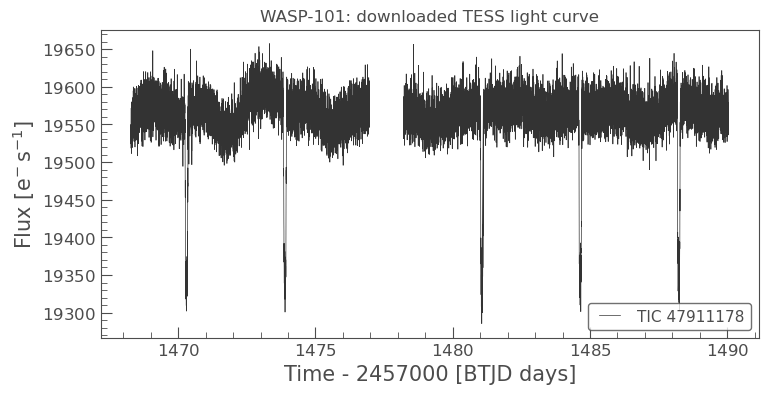

In [55]:
lc = search[0].download()

print(lc)
lc.plot()
plt.title(f"{target}: downloaded TESS light curve")
plt.show()

# 3. Clean and normalize the light curve
Real spacecraft photometry contains missing points, flagged cadences, instrumental trends, and astrophysical variability.

We first remove NaNs and normalize the flux around unity.

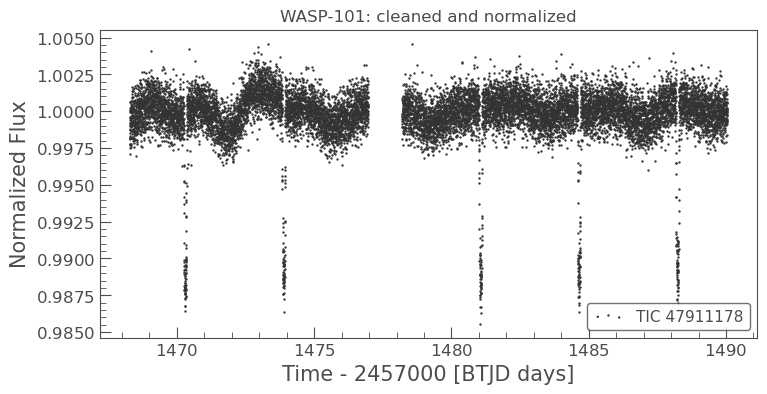

In [56]:
clean_lc = lc.remove_nans().normalize()

clean_lc.scatter(s=2)
plt.title(f"{target}: cleaned and normalized")
plt.show()

# 4. Detrend / flatten
Slow trends can dominate a period search. `flatten()` estimates a smooth baseline and divides it out.

**Important:** detrending choices can distort transits if the window is chosen badly. Never treat preprocessing as a purely cosmetic step.

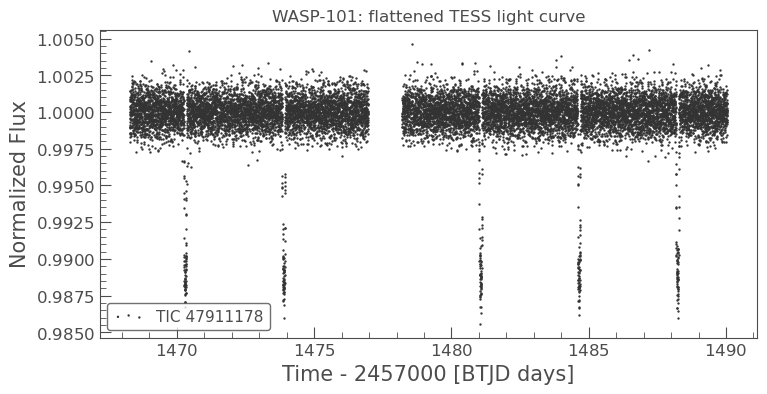

In [57]:
flat_lc = clean_lc.flatten(window_length=401)

flat_lc.scatter(s=2)
plt.title(f"{target}: flattened TESS light curve")
plt.show()

# 5. Lomb-Scargle periodogram
A periodogram asks: **which trial periods explain repeated variability particularly well?**

Lomb-Scargle is excellent for sinusoidal or approximately sinusoidal signals and uneven sampling. It is widely used for stellar rotation, pulsations, and other periodic variability.

A transit, however, is not sinusoidal. Therefore, a Lomb-Scargle peak should **not** automatically be interpreted as an orbital period or a planet.

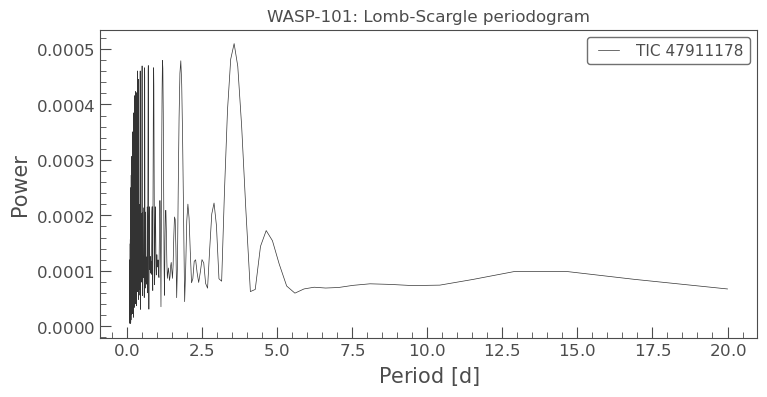

Strongest Lomb-Scargle period: 3.575913603186792 d


In [58]:
pg = flat_lc.to_periodogram(
    method="lombscargle",
    minimum_period=0.1,
    maximum_period=20.0
)

pg.plot(view="period")
plt.title(f"{target}: Lomb-Scargle periodogram")
plt.show()

ls_period = pg.period_at_max_power
print("Strongest Lomb-Scargle period:", ls_period)

## Discussion: what can produce a periodogram peak?
A strong peak can arise from:
- stellar rotation and starspots;
- pulsations;
- eclipses/transits and their harmonics;
- spacecraft/instrumental systematics;
- sampling aliases.

**Key lesson:** periodicity is evidence of repetition, not evidence of a planet.

# 6. Fold at the strongest Lomb-Scargle period
Phase folding overlays repeated cycles. If the selected period is physically meaningful, coherent structure should become easier to see.

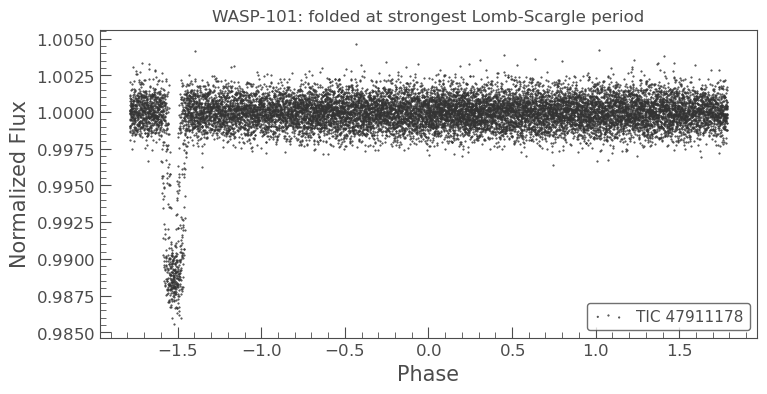

In [59]:
folded_ls = flat_lc.fold(period=ls_period)

folded_ls.scatter(s=1)
plt.title(f"{target}: folded at strongest Lomb-Scargle period")
plt.xlabel("Phase")
plt.show()

### Ask the class
1. Is the folded signal sinusoidal, eclipse-like, or messy?
2. Does the strongest Lomb-Scargle period look like the transit period?
3. Could the peak be a harmonic?

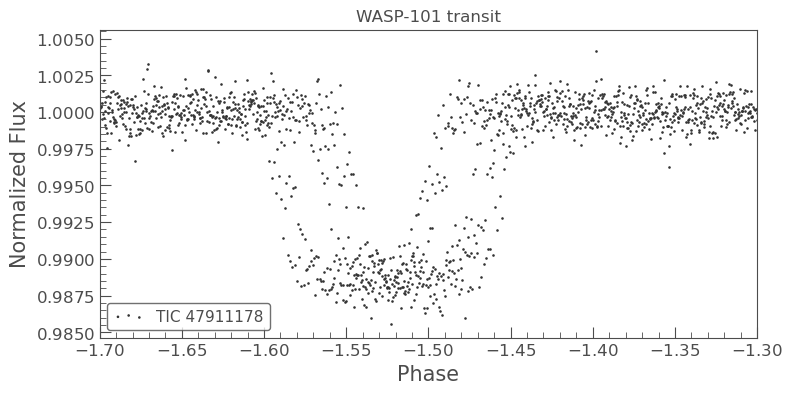

In [86]:
folded_ls.scatter(s=3)

plt.xlim(-1.7, -1.3)
# plt.ylim(0.987, 1.003)

plt.title("WASP-101 transit")
plt.xlabel("Phase")
plt.ylabel("Normalized Flux")
plt.show()

# 7. Fold at the known orbital period


This lets us compare a known transit period with what Lomb-Scargle found.

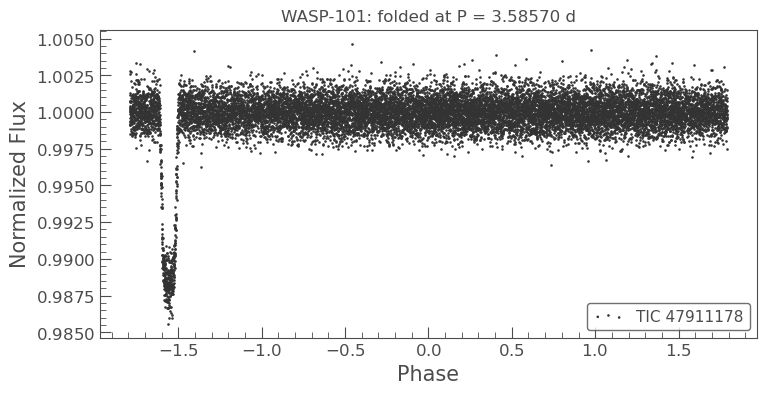

In [87]:
known_period = 3.5857  # days, approximate literature value for WASP-101 b

folded_known = flat_lc.fold(period=known_period)

folded_known.scatter(s=3)
plt.title(f"{target}: folded at P = {known_period:.5f} d")
plt.xlabel("Phase")
# plt.xlim(-0.15, 0.15)
plt.show()

# 8. Bin the folded transit
Binning reduces point-to-point scatter and makes the average transit shape easier to discuss.

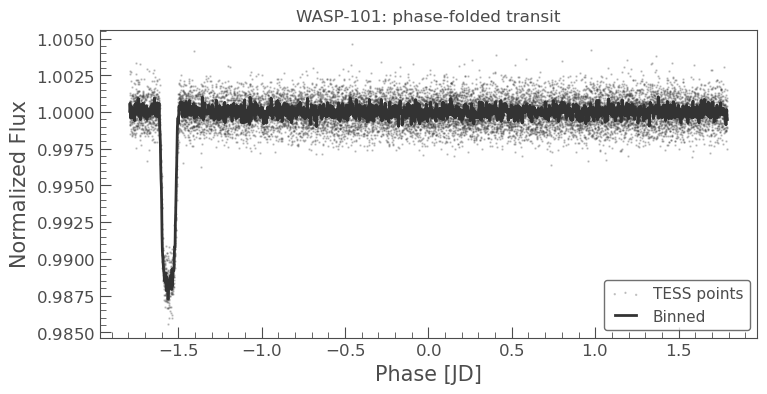

In [88]:
binned = folded_known.bin(time_bin_size=0.002)

ax = folded_known.scatter(s=2, alpha=0.25, label="TESS points")
binned.plot(ax=ax, linewidth=2, label="Binned")
# plt.xlim(-0.12, 0.12)
plt.title(f"{target}: phase-folded transit")
plt.show()

# 9. Estimate the transit depth

For a simple transit with negligible contaminating light,

$$
\delta \approx \left(\frac{R_p}{R_\star}\right)^2
$$

So an approximate radius ratio is

$$
\frac{R_p}{R_\star} \approx \sqrt{\delta}
$$

Below we estimate the depth from a small phase interval around transit. This is intentionally simple for teaching; a scientific analysis would fit a physical transit model.

In [89]:
phase = np.asarray(folded_known.time.value)
flux = np.asarray(folded_known.flux.value)

# Remove non-finite values
good = np.isfinite(phase) & np.isfinite(flux)
phase = phase[good]
flux = flux[good]

# Find points belonging to the deepest part of the transit
threshold = np.nanpercentile(flux, 2)

deep_points = flux <= threshold

# Median position of those low-flux points
transit_center = np.nanmedian(phase[deep_points])

print("Estimated transit centre:", transit_center)

Estimated transit centre: -1.5578976281600552


In [90]:
# Regions relative to measured transit centre
in_transit = np.abs(phase - transit_center) < 0.035

out_transit = (
    (np.abs(phase - transit_center) > 0.07) &
    (np.abs(phase - transit_center) < 0.15)
)

print("In-transit points:", np.sum(in_transit))
print("Out-of-transit points:", np.sum(out_transit))

f_in = np.nanmedian(flux[in_transit])
f_out = np.nanmedian(flux[out_transit])

depth = (f_out - f_in) / f_out
radius_ratio = np.sqrt(depth)

print(f"Out-of-transit flux:       {f_out:.5f}")
print(f"In-transit flux:           {f_in:.5f}")
print(f"Transit depth:             {100*depth:.3f}%")
print(f"Rp/Rstar:                  {radius_ratio:.3f}")

In-transit points: 252
Out-of-transit points: 576
Out-of-transit flux:       1.00005
In-transit flux:           0.98863
Transit depth:             1.142%
Rp/Rstar:                  0.107


# 10. Why astronomers also use BLS
Lomb-Scargle is an important general period-search tool, but exoplanet transits are closer to repeating **boxes** than repeating sine waves.

**Box Least Squares (BLS)** explicitly searches for periodic decreases in brightness.

This short comparison is useful because it shows students that the algorithm should match the signal morphology.

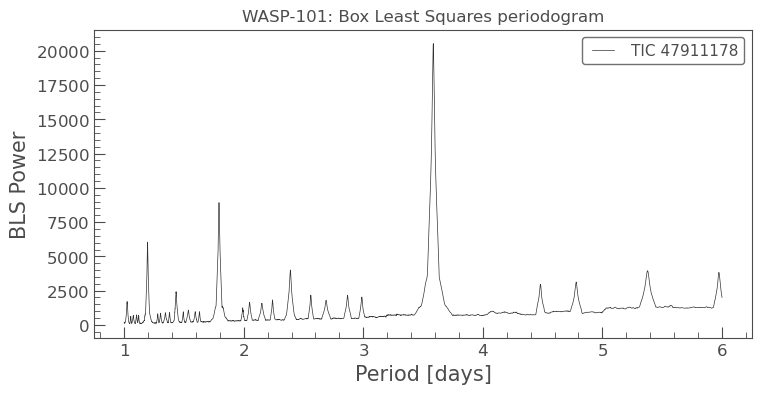

Best BLS period: 3.58612 days


In [91]:
import numpy as np

bls = flat_lc.to_periodogram(
    method="bls",
    minimum_period=1.0,
    maximum_period=6.0,
    duration=np.linspace(0.05, 0.20, 10),
    frequency_factor=1
)

bls.plot(view="period")

plt.title(f"{target}: Box Least Squares periodogram")
plt.xlabel("Period [days]")
plt.show()

bls_period = bls.period_at_max_power

print(f"Best BLS period: {bls_period.value:.5f} days")

# 11. Optional extension: combine multiple TESS sectors
If time permits, download all available SPOC light curves and stitch them together.

More baseline can improve period recovery, but sector-to-sector offsets and systematics need attention.

In [84]:
# Optional -
# collection = search.download_all()
# stitched = collection.stitch().remove_nans().normalize()
# stitched.scatter(s=1)
# plt.title(f"{target}: stitched TESS sectors")
# plt.show()

# 12. Exoplanet or eclipsing binary?
For a second target, try to inspect:
- transit/eclipsing depth;
- primary versus secondary eclipse;
- odd/even depth differences;
- V-shaped versus flat-bottomed events;
- out-of-eclipse variability;
- whether folding at twice the candidate period changes the interpretation.

A deep eclipse or visible secondary eclipse can indicate a stellar companion, although morphology alone is not definitive.

This is why TESS candidates require **follow-up**:
1. ground-based time-series photometry;
2. high-resolution imaging / contamination checks;
3. stellar spectroscopy;
4. radial velocities;
5. if appropriate, atmospheric spectroscopy after confirmation.

# 13. Student challenge
Choose another target and repeat the workflow.

```python
target = "YOUR TARGET HERE"
search = lk.search_lightcurve(target, mission="TESS")
```

### Questions to answer
1. Which sectors observed your target?
2. What does the raw light curve look like?
3. What is the strongest Lomb-Scargle period?
4. What happens when you fold at that period?
5. Is the variability sinusoidal or transit-like?
6. Does BLS recover a different period?
7. What follow-up observation would you request next?

# Take-home messages
- TESS measures **brightness as a function of time**.
- Light curves contain astrophysics **and** instrumental effects.
- Lomb-Scargle searches for periodicity, but a peak does not identify its physical cause.
- Phase folding tests whether repeated structure is coherent.
- Transit depth gives a first-order estimate of the planet-to-star radius ratio.
- BLS is generally better matched to transit-shaped signals.
- A TESS transit is a **candidate** until false positives are addressed with follow-up observations.

### Useful resources
- Lightkurve documentation: https://lightkurve.github.io/lightkurve/
- MAST TESS archive: https://archive.stsci.edu/missions-and-data/tess
- NASA TESS mission: https://science.nasa.gov/mission/tess/